In [1]:
#Use cropscape, yvonne allen's gcpo lcc flood frequency dataset, wmu, and wrep to calculate available energy.

In [2]:
import rasterio
import geopandas as gpd
from rasterio.mask import mask
import numpy as np
from rasterio.plot import show
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from shapely.geometry import box, shape
import duckdb

# 1 corn, 3 rice, 4 sorghum, 5 soybeans, 29 millet, 63 forest, 83 water, 87 wetlands, 92 aquaculture,
#111 open water, 141 deciduous forest, 190 woody wetlands, 195 herbaceous wetlands
habitats = {1:'Corn', 3:'Rice', 4:'Sorghum', 5:'Soybeans', 29:'Millet', 83:'OpenWater', 87:'EmergentWetlands', 92:'Aquaculture', 111:'OpenWater',190: 'WoodyWetlands', 195:'EmergentWetlands'}



In [3]:
###############################################
#
#
# Read flooded crops by merging cropscape and GCPO LCC Flood > 20 
#
#
###############################################

In [4]:
'''Read in NLCD, mask with aoi.  Mask out all but urban classes and set urban values to 1.'''
cogin = 'D:\gis\BaseData\cdl_2024_30m.tif'
cog = rasterio.open(cogin)

# Azure Blob Storage URL
url = "abfs://publicparquet/MAV_Boundary.parquet"
# Storage account credentials
storage_options = {
    "account_name": "giscog"
}
# Read the Parquet file directly into a GeoDataFrame
gdf = gpd.read_parquet(url, storage_options=storage_options)
gdf = gdf.to_crs(cog.crs)

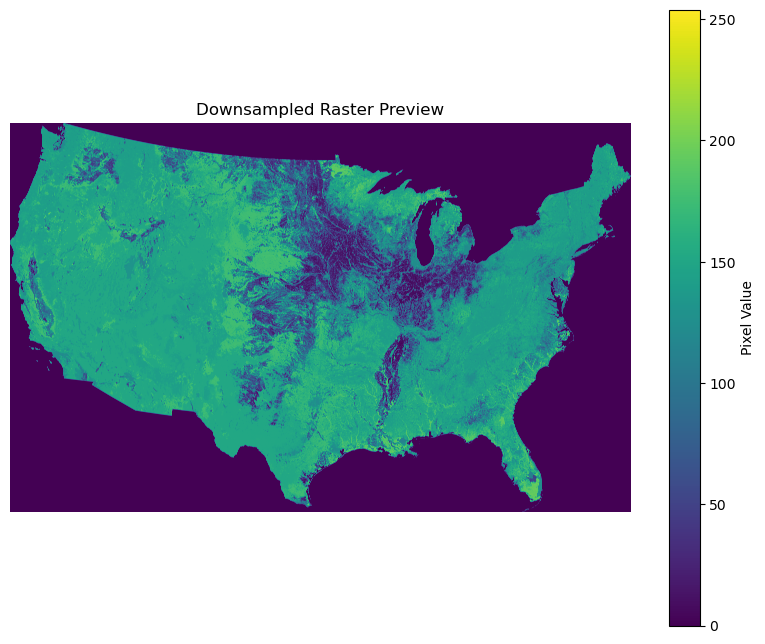

In [5]:
# Define a downsampling factor (adjust as needed)
downsample_factor = 10

# Calculate the shape of the downsampled image
out_shape = (
    cog.count,
    cog.height // downsample_factor,
    cog.width // downsample_factor
)

# Read the first band with downsampling
data = cog.read(
    1,
    out_shape=out_shape,
    resampling=Resampling.nearest
)

# Plot the downsampled raster
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap='viridis')
plt.title("Downsampled Raster Preview")
plt.colorbar(label='Pixel Value')
plt.axis('off')
plt.show()

(28880, 9095)
Unique values in crop:
[  0   1   2   3   4   5   6  10  12  13  14  21  24  26  27  28  29  36
  37  42  43  44  45  46  47  48  49  50  53  54  57  58  59  60  61  67
  68  69  71  72  74  76  92 111 121 122 123 124 131 141 142 143 152 176
 190 195 205 209 212 219 220 221 222 225 226 229 236 238 240 242 243 254]


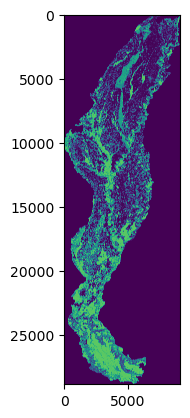

<Axes: >

In [6]:
crop, crop_transform =rasterio.mask.mask(cog, gdf.dissolve().geometry, crop=True)
crop = crop[0]
print(crop.shape)
unique_values = np.unique(crop[~np.isnan(crop)])
print("Unique values in crop:")
print(unique_values)
show(crop)

In [7]:
target_classes = [1, 3, 4, 5, 29, 63, 83, 87, 92, 111, 141, 190, 195]
# 1 corn, 3 rice, 4 sorghum, 5 soybeans, 29 millet, 63 forest, 83 water, 87 wetlands, 92 aquaculture, 111 open water, 141 deciduous forest, 190 woody wetlands, 195 herbaceous wetlands
binary_mask = np.isin(crop, target_classes).astype(np.uint8)
binary_mask = binary_mask
crop = np.where(binary_mask, crop, np.nan)
unique_values = np.unique(crop[~np.isnan(crop)])
print("Unique values in crop:")
print(unique_values)

Unique values in crop:
[  1.   3.   4.   5.  29.  92. 111. 141. 190. 195.]


EPSG:5070


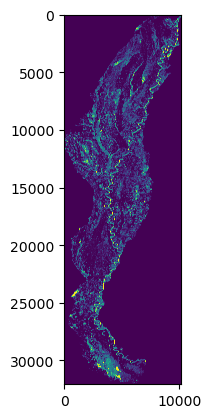

<Axes: >

In [8]:
'''Read in NLCD, mask with aoi.  Mask out all but urban classes and set urban values to 1.'''
floodin = 'https://giscog.blob.core.windows.net/publiccogs/GCPO_IF_albers.tif'
floodread = rasterio.open(floodin)
print(floodread.crs)
flood, flood_transform =rasterio.mask.mask(floodread, gdf.dissolve().geometry, crop=True)
show(flood)

In [9]:
from rasterio.warp import reproject, Resampling

# Prepare an empty array to hold the resampled flood data
resampled_flood = np.empty_like(crop, dtype=flood.dtype)

# Reproject and resample flood to match crop
reproject(
    source=flood,
    destination=resampled_flood,
    src_transform=flood_transform,
    src_crs=floodread.crs,
    dst_transform=crop_transform,
    dst_crs=cog.crs,
    resampling=Resampling.nearest
)

# Create mask and extract crop values
flood_mask = resampled_flood >= 20
print('80', np.count_nonzero(flood_mask))
print('50', np.count_nonzero(resampled_flood >= 50))
print('20', np.count_nonzero(resampled_flood >= 20))
print('lt20', np.count_nonzero(resampled_flood < 20))
notflood_mask = resampled_flood < 20
flooded_crop_values = crop[flood_mask]

# Create a new array filled with NaNs
flooded_crop_2d = np.full(crop.shape, np.nan, dtype=np.float32)
notflooded_crop = np.full(crop.shape, np.nan, dtype=np.float32)
# Fill in the crop values where flood condition is met
flooded_crop_2d[flood_mask] = crop[flood_mask]
notflooded_crop[notflood_mask] = crop[notflood_mask]

80 26840667
50 11588238
20 26840667
lt20 235822933


In [12]:
print('crop', np.count_nonzero(crop >0))
print('notflooded crop', np.count_nonzero(notflooded_crop >0))
print('flooded crop', np.count_nonzero(flooded_crop_2d > 0))
print('')
print('notflooded crop %', np.count_nonzero(notflooded_crop >0)/np.count_nonzero(crop >0))
print('flooded crop %', np.count_nonzero(flooded_crop_2d > 0)/np.count_nonzero(crop >0))

crop 91072853
notflooded crop 65715995
flooded crop 25356858

notflooded crop % 0.721576110062128
flooded crop % 0.27842388993787204


In [11]:
print(crop.shape)
unique_values = np.unique(crop[~np.isnan(crop)])
print("Unique values in crop:")
print(unique_values)
print(resampled_flood.shape)
#show(flooded_crop_2d)

(28880, 9095)
Unique values in crop:
[  1.   3.   4.   5.  29.  92. 111. 141. 190. 195.]
(28880, 9095)


In [11]:

unique_values = np.unique(flooded_crop_2d[~np.isnan(flooded_crop_2d)])

print("Unique values in flooded_crop_2d:")
print(unique_values)


Unique values in flooded_crop_2d:
[  1.   3.   4.   5.  29.  92. 111. 141. 190. 195.]


crop count 35016086


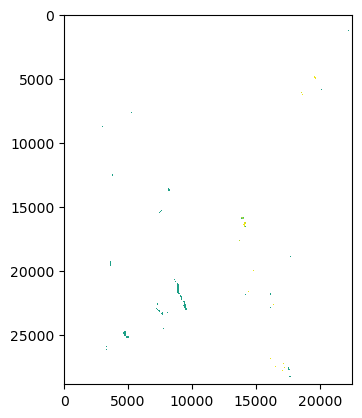

<Axes: >

In [12]:
print('crop count', np.count_nonzero(flooded_crop_2d >= 1))
show(flooded_crop_2d)

In [13]:
shapes = rasterio.features.shapes(flooded_crop_2d, transform=crop_transform)

# Separate geometries and values
geometries = []
values = []

for geom, value in shapes:
    geometries.append(shape(geom))
    values.append(value)

# Create GeoDataFrame with both geometry and raster value
gdf_vector = gpd.GeoDataFrame({'geometry': geometries, 'raster_value': values})
gdf_vector = gdf_vector.set_geometry('geometry')
gdf_vector = gdf_vector.set_crs(5070)

#gdf_vector = gdf_vector.to_wkt().geometry
gdf_vector.head()

,geometry,raster_value
0,"POLYGON ((567435 1599735, 567435 1599705, 5674...",111.0
1,"POLYGON ((567615 1599735, 567615 1599705, 5676...",5.0
2,"POLYGON ((567195 1599705, 567195 1599675, 5672...",190.0
3,"POLYGON ((567225 1599675, 567225 1599645, 5672...",5.0
4,"POLYGON ((567135 1599705, 567135 1599615, 5671...",111.0


In [14]:
gdf_vector['Class'] = gdf_vector['raster_value'].map(habitats)
floodedcrops = gdf_vector

In [15]:
###############################################
#
#
# Read WRP from PADUS
#
#
###############################################

In [16]:
print(gdf)
gdf = gdf.to_wkb()
#gdf_vector['geometry'] = gdf_vector.to_wkt().geometry
'''
Read in PADUS
'''
con = duckdb.connect()
con.install_extension("spatial")
con.load_extension("spatial")
con.install_extension("azure")
con.load_extension("azure")

con.sql('''CREATE OR REPLACE TABLE jvaoi AS SELECT * EXCLUDE geometry, ST_Geomfromwkb(geometry) AS geometry from gdf''')

   OBJECTID  AREA            PERIMETER                 ACRES  \
0         1  None  2877110.85099999979  25444979.37900000438   

               HECTARES         BufferDist    SqKM BCR_NAME  \
0  10297217.82200000063  10000.00000000000  102972     None   

            Shape_Leng Shape_Area  \
0  4044245.38767000008       None   

                                            geometry  
0  MULTIPOLYGON (((567119.705 1599715.987, 567022...  


In [17]:
con.sql("""
CREATE OR REPLACE TABLE prot AS 
SELECT Unit_Nm, geometry FROM read_parquet('D:\\gis\\BaseData\\padus_fee_easement.parquet')
WHERE Unit_Nm LIKE '%WRP%' OR Unit_Nm LIKE '%WREP%'
""")

In [18]:
con.sql("""
CREATE OR REPLACE TABLE wrp AS 
SELECT Unit_Nm, ST_Intersection(jvaoi.geometry, st_buffer(prot.geometry,0)) as geometry
FROM prot
JOIN jvaoi ON 
ST_Intersects(jvaoi.geometry, st_buffer(prot.geometry,0))
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [19]:
from shapely import wkt, wkb
# Need huc12 geometry
wrpdf = con.sql('SELECT ST_AsText(geometry) as geometry from wrp').df()
wrpdf['geometry'] = wrpdf['geometry'].apply(wkt.loads)
wrpdf = gpd.GeoDataFrame(wrpdf, geometry='geometry', crs=5070)

In [20]:
wrpdf.head()

,geometry
0,"MULTIPOLYGON (((605406.214 1543979.297, 605477..."
1,"POLYGON ((610029.916 1551937.376, 610032.955 1..."
2,"MULTIPOLYGON (((607388.53 1535208.108, 606820...."
3,"POLYGON ((604900.915 1583450.145, 604903.427 1..."
4,"POLYGON ((592084.056 1519555.559, 592093.278 1..."


In [21]:
###############################################
#
#
# Read WMU from parquet
#
#
###############################################

In [22]:
# Azure Blob Storage URL
wmuurl = "abfs://publicparquet/wmu_7_2025.parquet"
storage_options = {
    "account_name": "giscog"
}
# Read the Parquet file directly into a GeoDataFrame
wmu = gpd.read_parquet(wmuurl, storage_options=storage_options)

In [23]:
print(wmu['HabitatTyp'].unique())
wmu.loc[wmu.HabitatTyp=='Woody Wetland', ['HabitatTyp']] = 'woodywetlands'
wmu.loc[wmu.HabitatTyp=='Open Water', ['HabitatTyp']] = 'openwater'
wmu.loc[wmu.HabitatTyp=='Herbaceous Wetlands', ['HabitatTyp']] = 'emergentwetlands'
wmu.loc[wmu.HabitatTyp=='Open-aquatic', ['HabitatTyp']] = 'aquaculture'
wmu.loc[wmu.HabitatTyp=='Open-Aquatic', ['HabitatTyp']] = 'aquaculture'
wmu.loc[wmu.HabitatTyp=='Moist-Soil', ['HabitatTyp']] = 'moistsoil'
wmu.loc[wmu.HabitatTyp=='Reforested hardwoods', ['HabitatTyp']] = 'hardwoods'
wmu.loc[wmu.HabitatTyp=='Hardwoods', ['HabitatTyp']] = 'hardwoods'
wmu.loc[wmu.HabitatTyp=='Forested swamp', ['HabitatTyp']] = 'woodywetlands'
wmu['HabitatTyp'] = wmu['HabitatTyp'].str.lower()
print(wmu['HabitatTyp'].unique())

['Open-Aquatic' 'Moist-Soil' 'Woody Wetland' 'Open-aquatic' 'Cropland'
 'Rice' 'WRP' 'Corn' 'Soybeans' 'Milo' 'Millet' 'Hardwoods'
 'Reforested hardwoods' 'Mudflat' 'Forested swamp' 'Shrub swamp' 'Fallow'
 None 'Other']
['aquaculture' 'moistsoil' 'woodywetlands' 'cropland' 'rice' 'wrp' 'corn'
 'soybeans' 'milo' 'millet' 'hardwoods' 'mudflat' 'shrub swamp' 'fallow'
 None 'other']


In [24]:
import pandas as pd
wmu = wmu.rename(columns={'HabitatTyp': 'Class'})
wmu['source'] = 'wmu'
wrpdf['source'] = 'wrp'
floodedcrops['source'] = 'floodedcropscape'
print('wmu', (wmu.area*0.000247105).sum())
print('wrpdf', (wrpdf.area*0.000247105).sum())
print('floodedcrops', (floodedcrops.area*0.000247105).sum())
wrpdf['Class'] = 'wrp'
merged_gdf = pd.concat([wmu, wrpdf], ignore_index=True)
merged_gdf = pd.concat([merged_gdf, floodedcrops], ignore_index=True)
merged_gdf = gpd.GeoDataFrame(merged_gdf, geometry='geometry', crs=wmu.crs)

wmu 503329.57789639547
wrpdf 774309.399637406
floodedcrops 144524791.60632002


In [25]:
merged_gdf['acres'] = merged_gdf.area * 0.000247105
merged_gdf = merged_gdf.dropna(subset=['Class'])
merged_gdf = merged_gdf.drop(columns=['Acre', 'raster_value'])
print(merged_gdf['acres'].sum())
merged_gdf.head()

8957833.849547857


,Class,OakPCT,HrvstPCT,Functional,MSProd,Reviewed,geometry,source,acres
0,aquaculture,0.0,0.0,Yes,Low,No,"MULTIPOLYGON (((378749.057 899336.826, 378759....",wmu,5542.008821
1,moistsoil,0.0,0.0,Yes,Medium,Yes,"MULTIPOLYGON (((114128.309 1192439.344, 114129...",wmu,160.371597
2,moistsoil,0.0,0.0,Yes,Medium,Yes,"MULTIPOLYGON (((61140.168 1210898.604, 61114.3...",wmu,62.604853
3,moistsoil,0.0,0.0,Yes,Medium,Yes,"MULTIPOLYGON (((48307.57 1234232.663, 48268.25...",wmu,95.819668
4,moistsoil,0.0,0.0,Yes,Medium,Yes,"MULTIPOLYGON (((89667.057 1205527.63, 89404.74...",wmu,83.141301


In [1]:
len(merged_gdf)

NameError: name 'merged_gdf' is not defined

In [26]:
print('count',len(merged_gdf))
print('area sum',(merged_gdf.area*0.000247105).sum())
print('acres sum',merged_gdf['acres'].sum())

count 1633724
area sum 8957833.849547857
acres sum 8957833.849547857


In [27]:
merged_gdf.to_parquet('merged_gdf.parquet')